---

### eChem course module on:

# [The MCSCF method](https://kthpanor.github.io/echem/mcscf/)

### [Patrick Norman](https://www.kth.se/profile/panor)

#### [KTH Royal Institute of Technology](https://www.kth.se/), Stockholm, Sweden

---

In [ ]:
import multipsi as mtp
import veloxchem as vlx

## Introduction

The multiconfigurational self‑consistent field (MCSCF) method is a central electronic‑structure approach for systems where a single‑determinant description is insufficient. In situations involving strong (static) electron correlation—such as bond breaking, near‑degeneracies, open‑shell states, or excited states—methods like Hartree–Fock can qualitatively fail.

In MCSCF, the electronic wave function is expanded as a linear combination of multiple configuration state functions (CSFs) or determinants in a restricted basis of molecular orbitals, while simultaneously optimizing both the configuration coefficients and the molecular orbitals. This variational treatment allows the method to describe near‑degenerate electronic states in a balanced and physically meaningful way.

A widely used realization of MCSCF is the Complete Active Space SCF (CASSCF) method, where a selected set of electrons and orbitals (the active space) is treated explicitly in all possible configurations, while remaining orbitals are kept doubly occupied or unoccupied. The choice of active space is crucial and often guided by chemical intuition and preliminary calculations.

MCSCF methods provide a reliable reference for post‑SCF correlation methods, serve as a foundation for multistate and excited‑state calculations, and play a key role in modern quantum chemistry when qualitative correctness is essential.

The main drawbacks include:

- Lack of dynamic correlation
- Strong dependence on the choice of active space (far from black-box)
- Lack of size consistency
- Limited transferability, results from an MCSCF calculation are often:
  - system‑specific
  - geometry‑dependent
  - sensitive to symmetry breaking or near‑degeneracies

## Define molecular system

### Get initial structure and choose a basis set

In [ ]:
molecule = vlx.Molecule.read_name("acetylene")
basis = vlx.MolecularBasis.read(molecule, "6-31g**")

In [ ]:
molecule.show(atom_indices=True)

### Optimize the molecular structure

In [ ]:
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_results = opt_drv.compute(molecule, basis, scf_results)

### Retrieve optimized geometry and (optionally) perform a bend

In [ ]:
molecule = vlx.Molecule.read_xyz_string(opt_results["final_geometry"])

# Exercise: select whether to bend or not
bend = True

if bend:
    molecule.set_angle_in_degrees((3, 1, 2), 120)
    molecule.set_angle_in_degrees((1, 2, 4), 120)
    molecule.set_dihedral_in_degrees((3, 1, 2, 4), 0)

### Analyze symmetry and reorient to standard orientation

In [ ]:
pg = vlx.SymmetryAnalyzer()

pg_results = pg.identify_pointgroup(molecule, tolerance="very tight")
molecule = pg.symmetrize_pointgroup(pg_results)

In [ ]:
pg.print_symmetry_results(pg_results)

In [ ]:
molecule.show(atom_indices=True)

## Case study

A central challenge in MCSCF calculations is the selection of an appropriate active space, that is, identifying which orbitals must be treated on an equal multiconfigurational footing. The active space should include orbitals that are partially occupied, nearly degenerate, or strongly involved in the chemical process of interest, such as bond formation or breaking, low‑lying excited states, or open‑shell character.

Standard SCF orbitals are often delocalized and ordered by energy, which can obscure the chemically relevant orbitals needed for the active space. As a result, naïvely choosing the highest‑occupied and lowest‑unoccupied orbitals may lead to an unbalanced or qualitatively incorrect description. In particular, missing a key orbital can cause the MCSCF wave function to collapse back toward a single‑reference solution, while including unnecessary orbitals can make the calculation prohibitively expensive and difficult to converge.

Constructing a good active space therefore requires chemical insight combined with diagnostic tools, such as orbital occupation numbers, symmetry analysis, and visualization of orbitals. The goal is to include all orbitals essential for resolving near‑degeneracies and static correlation, while excluding those that remain well described as either doubly occupied or virtual.

### Important configurations for bent acetylene

Bent acetylene has important biradical and ionic configurations. HF provides no flexibility to alter the mix of these configurations and so a multi-configurational wave function is called for.

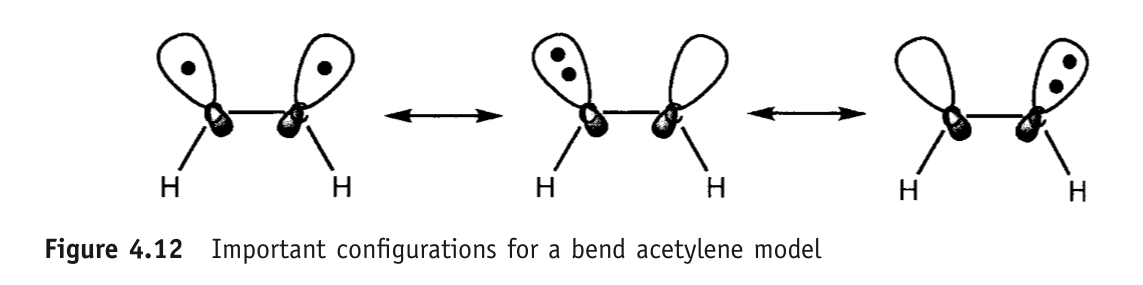

### Obtain initial orbitals with HF

In [ ]:
scf_drv = vlx.ScfRestrictedDriver()
scf_results = scf_drv.compute(molecule, basis)

In [ ]:
scf_drv.molecular_orbitals.print_orbitals(molecule, basis)

In [ ]:
viewer_scf = vlx.OrbitalViewer()
viewer_scf.plot(molecule, basis, scf_drv.mol_orbs)

### Define active space and optimize MCSCF state

Bent acetylene is a textbook example of how geometry changes create electronic near‑degeneracies.
The bending motion transforms acetylene from a well‑behaved closed‑shell molecule into a system with diradical character, which is why the π/π* orbitals must be treated on equal footing in a CASSCF description

In [ ]:
mcscf_drv = mtp.McscfDriver()
orbital_space = mtp.OrbSpace(molecule, basis, scf_drv.mol_orbs)
orbital_space.cas(2, 2)

# Exercise: introduce MC-PDFT
#mcscf_drv.xcfun = "tBLYP"

mcscf_results = mcscf_drv.compute(molecule, basis, orbital_space)

In [ ]:
mcscf_results["ci_vectors"].print(0)

In [ ]:
viewer_mcscf = vlx.OrbitalViewer()
viewer_mcscf.plot(molecule, basis, orbital_space.molecular_orbitals)

### Numerical results

#### Occupation numbers

Linear acetylene:
````
CAS(10,10):
  CAS(4,4):
  CAS(2,2):
````

Bent acetylene:
````
CAS(10,10):
  CAS(4,4):
  CAS(2,2):
````

## Conclusions

- The HF wave function provides an adequate description of linear acetylene but not the bent configuration
- The CAS(2,2) wave function is the minimal MCSCF wave function to describe the important configurations of bent acetylene
- The CAS(4,4) wave function represents a significant additional improvement with occupation numbers close to those of the full valence CAS(10,10) wave function